In [1]:
import os
import glob
from datetime import datetime

from eoutils import S1Processor

# Found two scenes with overlap over landfast ice
zip_1 = '/dmidata/projects/asip/sentinel1/arctic/S1C_EW_GRDM_1SDH_20260408T175547_20260408T175647_007128_00E6F7_62FA.SAFE.zip'
zip_2 = '/dmidata/projects/asip/sentinel1/arctic/S1A_EW_GRDM_1SDH_20260409T080243_20260409T080343_064000_080D45_2356.SAFE.zip'

In [23]:
## Helper functions

# Function that upsamples the GCP coordinates to <new_grid_shape>. Useful when we want a lat/lon coordinate for each pixel in the SAR image
def upsample_gcp_grid_RectBiSpl(lines, samples, x, y, new_grid_shape):
    import numpy as np
    from scipy import interpolate

    upsampled_lines = np.linspace(0, lines.max(), new_grid_shape[0])
    upsampled_samples = np.linspace(0, samples.max(), new_grid_shape[1])

    x_interp = interpolate.RectBivariateSpline(lines[:, 0], samples[0], x)
    y_interp = interpolate.RectBivariateSpline(lines[:, 0], samples[0], y)

    x_up = x_interp(upsampled_lines, upsampled_samples)
    y_up = y_interp(upsampled_lines, upsampled_samples)

    return x_up, y_up

# Function to transform coordinates between different projections (using EPSG codes for the projections, e.g. 4326 for lat/lon, 3411 for North Polar Stereographic proj.)
def transform_points(x, y, fromEPSG, toEPSG):
    import pyproj
    from pyproj import Transformer

    transformer = Transformer.from_crs(pyproj.CRS(f'EPSG:{fromEPSG}'), pyproj.CRS(f'EPSG:{toEPSG}'), always_xy=True)
    x, y = transformer.transform(x, y)

    return x, y

In [24]:
# We need the coordinates and HH/HV bands from each scene.

s1p = S1Processor(zip_1)

# in-built function in the S1Processor class to transform the GCPs between projections. 
# In the original product the GCPs are given in lat/lon. 
# We transform to 3411 because we need a planar projection to set the GCPs to sea level and to upsample the GCP grid accurately (too much distortion in lat/lon). 
s1p._transform_gcps(3411)  
s1p._set_gcps_to_sea_level()

# Here, we count the number of "lines" and "samples" (i.e. rows and columns) in the GCP grid to get the GCP grid shape.
gcp_grid_shape = (len(s1p.gcps['sample'][s1p.gcps['sample'] == 0]), len(s1p.gcps.line[s1p.gcps.line == 0]))

# We use the helper function to upsample the GCP grid (now in 3411 projection), so we have a coordinate for each pixel in the SAR image.
X_1, Y_1 = upsample_gcp_grid_RectBiSpl(s1p.gcps.line.values.reshape(gcp_grid_shape),
    s1p.gcps['sample'].values.reshape(gcp_grid_shape),
    s1p.gcps.lon.values.reshape(gcp_grid_shape),
    s1p.gcps.lat.values.reshape(gcp_grid_shape),
    s1p.shape)

# Calibration and thermal noise removal
HH_1, HV_1 = s1p.process(calib='sigma', remove_thermal_noise=True)

[INFO: 2026-04-09 12:04:25: eoutils.S1Processor] Processesing started for S1C_EW_GRDM_1SDH_20260408T175547_20260408T175647_007128_00E6F7_62FA.SAFE.zip
[INFO: 2026-04-09 12:04:25: eoutils.S1Processor] Processing band 1/2: HH
[INFO: 2026-04-09 12:04:28: eoutils.S1Processor] Calibration and thermal noise removal...
[INFO: 2026-04-09 12:04:31: eoutils.S1Processor] Converting to dB...
[INFO: 2026-04-09 12:04:31: eoutils.S1Processor] Processing band 2/2: HV
[INFO: 2026-04-09 12:04:34: eoutils.S1Processor] Calibration and thermal noise removal...
[INFO: 2026-04-09 12:04:37: eoutils.S1Processor] Converting to dB...
[INFO: 2026-04-09 12:04:38: eoutils.S1Processor] Processing finished in 13.57s.


In [25]:
# We do this for both scenes

s1p = S1Processor(zip_2)
s1p._transform_gcps(3411)  
s1p._set_gcps_to_sea_level()
gcp_grid_shape = (len(s1p.gcps['sample'][s1p.gcps['sample'] == 0]), len(s1p.gcps.line[s1p.gcps.line == 0]))
X_2, Y_2 = upsample_gcp_grid_RectBiSpl(s1p.gcps.line.values.reshape(gcp_grid_shape),
    s1p.gcps['sample'].values.reshape(gcp_grid_shape),
    s1p.gcps.lon.values.reshape(gcp_grid_shape),
    s1p.gcps.lat.values.reshape(gcp_grid_shape),
    s1p.shape)

HH_2, HV_2 = s1p.process(calib='sigma', remove_thermal_noise=True)

[INFO: 2026-04-09 12:04:43: eoutils.S1Processor] Processesing started for S1A_EW_GRDM_1SDH_20260409T080243_20260409T080343_064000_080D45_2356.SAFE.zip
[INFO: 2026-04-09 12:04:43: eoutils.S1Processor] Processing band 1/2: HH
[INFO: 2026-04-09 12:04:46: eoutils.S1Processor] Calibration and thermal noise removal...
[INFO: 2026-04-09 12:04:49: eoutils.S1Processor] Converting to dB...
[INFO: 2026-04-09 12:04:50: eoutils.S1Processor] Processing band 2/2: HV
[INFO: 2026-04-09 12:04:52: eoutils.S1Processor] Calibration and thermal noise removal...
[INFO: 2026-04-09 12:04:56: eoutils.S1Processor] Converting to dB...
[INFO: 2026-04-09 12:04:56: eoutils.S1Processor] Processing finished in 13.43s.


In [ ]:
import pyresample

# Now we have the upsampled coordinates for both scenes. 
# Unfortunately, pyresample need lat/lon to do the resampling, so we need to project back from 3411 to 4326, and that takes some compute time...

lon_1, lat_1 = transform_points(X_1, Y_1, fromEPSG=3411, toEPSG=4326)
lon_2, lat_2 = transform_points(X_2, Y_2, fromEPSG=3411, toEPSG=4326)

# Pyresample relates the two scenes geographically using swath definitions
swath_def_1 = pyresample.SwathDefinition(lon_1, lat_1)
swath_def_2 = pyresample.SwathDefinition(lon_2, lat_2)

In [ ]:
import numpy as np

# Resampling using nearest neighbour..
# To resample multiple bands at the same time, we have to stack like HxWxC, with C being the bands.
# Below we resample both bands from scene 1 to the grid of scene 2. 
scene_1_resampled = pyresample.kd_tree.resample_nearest(
    swath_def_1, # source grid
    np.stack([HH_1, HV_1], axis=2), # source data
    swath_def_2, # target grid
    radius_of_influence=100, # 100 m
    fill_value=np.nan)

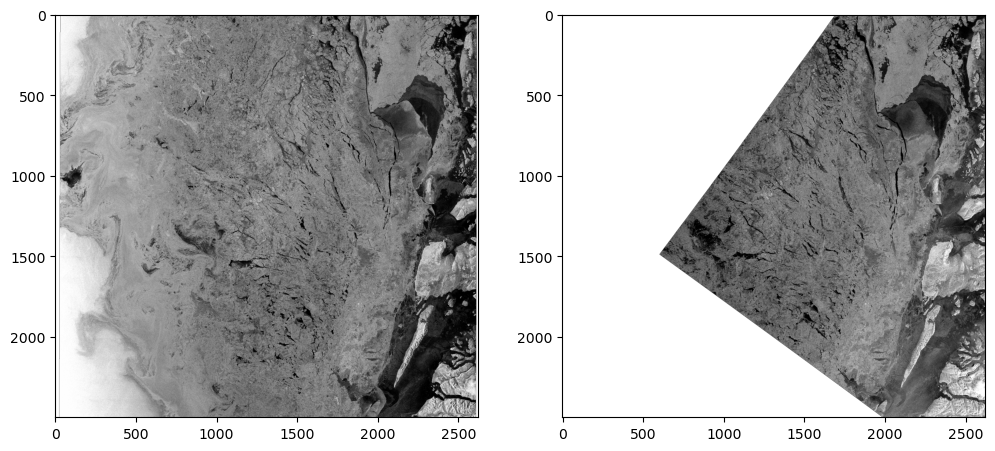

In [ ]:
import matplotlib.pyplot as plt

HH_1_resampled = scene_1_resampled[:, :, 0]

skip = 4 # skipping some pixels to plot faster
fig, ax = plt.subplots(1, 2, figsize=(12, 8))
ax[0].imshow(HH_2[::skip, ::skip], vmin=np.nanpercentile(HH_2, 2), vmax=np.nanpercentile(HH_2, 98), cmap='gist_gray')
ax[1].imshow(HH_1_resampled[::skip, ::skip], vmin=np.nanpercentile(HH_2, 2), vmax=np.nanpercentile(HH_2, 98), cmap='gist_gray')